In [1]:
from google.colab import files

files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download zalando-research/fashionmnist
!unzip fashionmnist.zip

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
  0% 0.00/68.8M [00:00<?, ?B/s]
100% 68.8M/68.8M [00:00<00:00, 1.36GB/s]
Archive:  fashionmnist.zip
  inflating: fashion-mnist_test.csv  
  inflating: fashion-mnist_train.csv  
  inflating: t10k-images-idx3-ubyte  
  inflating: t10k-labels-idx1-ubyte  
  inflating: train-images-idx3-ubyte  
  inflating: train-labels-idx1-ubyte  


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset , DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
torch.manual_seed(42)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
 df = pd.read_csv('/content/fashion-mnist_train.csv')

In [7]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(60000, 785)

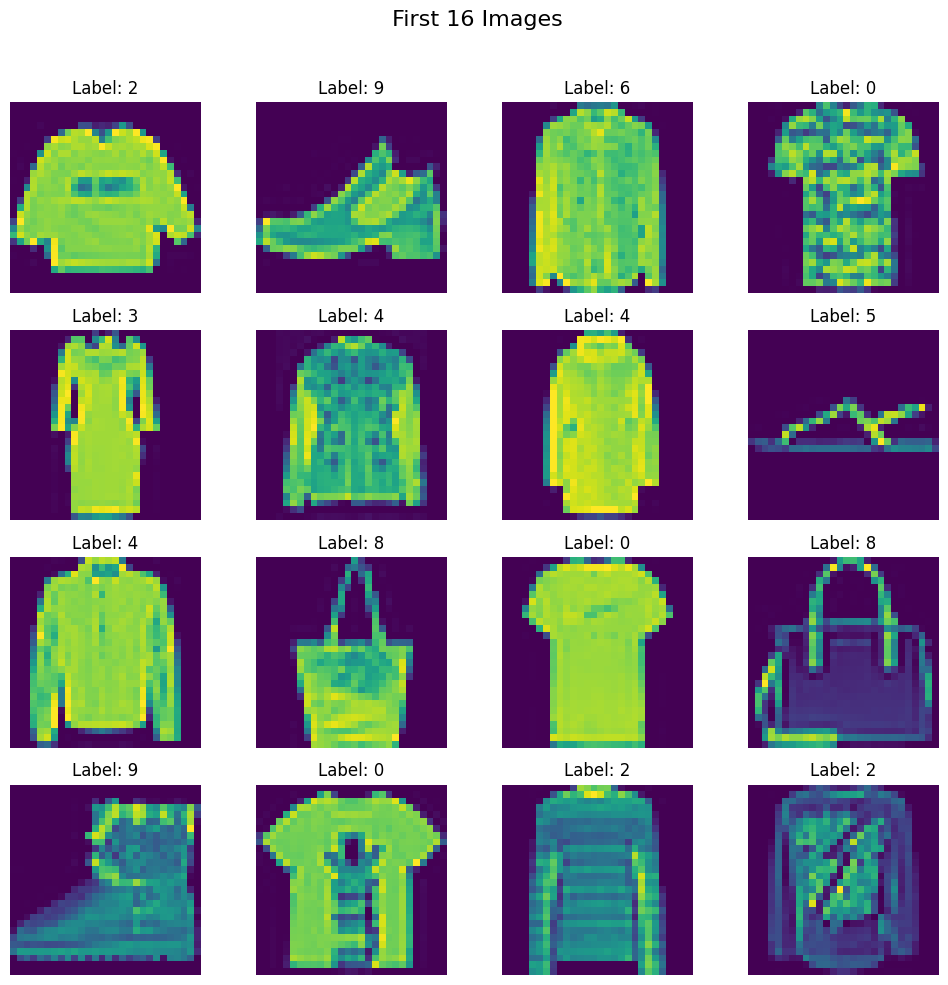

In [9]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle(" First 16 Images" , fontsize=16)

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i,0]}")


plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [10]:
x = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [11]:
x_train , x_test, y_train , y_test = train_test_split(x,y , test_size=0.2 , random_state=42)

In [12]:
x_train= x_train/255.0
x_test= x_test/255.0

In [13]:
x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [14]:
class CustomDataset(Dataset):

    def __init__(self, features , labels):

        self.features = torch.tensor(features , dtype=torch.float32)
        self.labels = torch.tensor(labels , dtype=torch.long)

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, index):
        return self.features[index] , self.labels[index]

In [15]:
train_dataset = CustomDataset(x_train, y_train)
test_dataset = CustomDataset(x_test , y_test)

In [16]:
len(train_dataset)

48000

In [17]:
train_loader = DataLoader(train_dataset , batch_size=1024 , shuffle=True , pin_memory=True)
test_loader = DataLoader(test_dataset , batch_size=1024 , shuffle=False , pin_memory=True)

In [18]:
len(train_loader)

47

In [19]:
class MyNN(nn.Module):

    def __init__(self , num_features):

        super().__init__()

        self.model= nn.Sequential(
            nn.Linear(num_features,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64,10)# by default internally softmax is implemented
        )


    def forward(self, x):

        return self.model(x)


In [20]:
learning_rate = 0.1
epochs = 100

In [21]:
model = MyNN(x_train.shape[1])
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate , weight_decay=1e-4)

In [22]:

for epoch in range(epochs):
    total_epoch_loss =0
    for batch_features , batch_labels in train_loader:
        # move data to gpu
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        #forward pass
        y_pred = model(batch_features)

        #loss calculate
        loss = criterion(y_pred, batch_labels)

        #zero grad for next epoch not needed accumulate for grad
        # It is better to make it zero before calculation than after
        optimizer.zero_grad()
        #backward pass
        loss.backward()
        #parameter update
        optimizer.step()
        total_epoch_loss = total_epoch_loss+ loss.item()

    print(f"Epoch: {epoch+1} -> Loss: {total_epoch_loss/len(train_loader)}")

Epoch: 1 -> Loss: 1.0924550206103223
Epoch: 2 -> Loss: 0.6655970545525246
Epoch: 3 -> Loss: 0.5720330058260167
Epoch: 4 -> Loss: 0.5280423601891132
Epoch: 5 -> Loss: 0.502147523646659
Epoch: 6 -> Loss: 0.47794551862047074
Epoch: 7 -> Loss: 0.46194372024941954
Epoch: 8 -> Loss: 0.4483087811064213
Epoch: 9 -> Loss: 0.4381673862325384
Epoch: 10 -> Loss: 0.4271169685302897
Epoch: 11 -> Loss: 0.4169876943243311
Epoch: 12 -> Loss: 0.41201215348345166
Epoch: 13 -> Loss: 0.4015626939053231
Epoch: 14 -> Loss: 0.3973276323460518
Epoch: 15 -> Loss: 0.39014943546437203
Epoch: 16 -> Loss: 0.38129218398256504
Epoch: 17 -> Loss: 0.37954119038074574
Epoch: 18 -> Loss: 0.37203770875930786
Epoch: 19 -> Loss: 0.36916560695526446
Epoch: 20 -> Loss: 0.36321276996998075
Epoch: 21 -> Loss: 0.3576700300612348
Epoch: 22 -> Loss: 0.354582002822389
Epoch: 23 -> Loss: 0.35380757489102954
Epoch: 24 -> Loss: 0.3463470828025899
Epoch: 25 -> Loss: 0.34568925043369864
Epoch: 26 -> Loss: 0.33750083471866366
Epoch: 27 -

In [23]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [24]:
total=0
correct=0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        # move data to gpu
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)


        outputs = model(batch_features)##give 1024,10

        _, predicted = torch.max(outputs,1)

        total = total + batch_labels.shape[0]
        correct = correct + (predicted==batch_labels).sum().item()

print(correct/total)

0.8866666666666667
